# Linear Models and Regularization

Notebook ini membahas **linear models** dan teknik **regularization** pada machine learning, khususnya untuk masalah regresi. Materi utama chapter ini meliputi Linear Regression, Ridge Regression, Lasso Regression, ElasticNet, teori regularisasi, serta polynomial regression untuk data dengan hubungan non-linear.

Notebook ini disusun dalam Bahasa Indonesia dengan ringkasan teori, rumus matematis dalam format Markdown/LaTeX yang dapat dirender, contoh kode, visualisasi, dan interpretasi hasil.

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami konsep dasar linear regression.
- Menjelaskan hubungan antara fitur, koefisien, intercept, prediksi, dan error.
- Menggunakan metrik evaluasi regresi seperti MSE, RMSE, MAE, dan R².
- Memahami masalah multicollinearity pada regresi.
- Menerapkan Ridge Regression dengan penalti L2.
- Menerapkan Lasso Regression dengan penalti L1.
- Memahami ElasticNet sebagai kombinasi Ridge dan Lasso.
- Menjelaskan bias-variance trade-off dalam regularization.
- Menggunakan polynomial features untuk menangani pola non-linear.
- Membandingkan performa beberapa model regresi.

## Persiapan Library

Library yang digunakan dalam notebook ini berasal dari `numpy`, `pandas`, `matplotlib`, dan `scikit-learn`. Dataset dibuat secara sintetis agar konsep linear model dan regularization dapat diamati secara langsung.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(123)
pd.set_option("display.max_columns", 120)

## Ringkasan Chapter

Linear model adalah salah satu model paling dasar dalam machine learning. Model ini mencoba menemukan hubungan matematis antara beberapa fitur input dan target output. Pada regresi linear, hubungan tersebut direpresentasikan dalam bentuk persamaan garis atau hyperplane.

Chapter ini juga membahas regularization, yaitu teknik untuk mengurangi kompleksitas model dengan menambahkan penalti terhadap koefisien model. Tujuannya adalah mencegah model terlalu mengikuti noise pada data training sehingga lebih mampu melakukan generalisasi pada data baru.

Topik utama pada chapter ini:

| Topik | Inti Pembahasan |
|---|---|
| Linear Regression | Model regresi dasar dengan hubungan linear |
| Ridge Regression | Regularisasi L2 untuk mengecilkan koefisien |
| Lasso Regression | Regularisasi L1 yang dapat membuat koefisien menjadi nol |
| ElasticNet | Kombinasi penalti L1 dan L2 |
| Regularization Theory | Mengatur trade-off antara model complexity dan generalization |
| Polynomial Regression | Memperluas linear model untuk pola non-linear |

## Introduction to Linear Models

Linear model digunakan untuk memodelkan hubungan antara variabel target dan satu atau lebih variabel fitur. Disebut linear karena prediksi model merupakan kombinasi linear dari fitur-fitur input.

Pada kasus sederhana satu fitur, model dapat dibayangkan sebagai garis lurus. Pada data dengan banyak fitur, model membentuk bidang atau hyperplane dalam ruang berdimensi tinggi.

Linear model sering digunakan karena:

- Mudah dipahami.
- Cepat dilatih.
- Dapat menjadi baseline yang baik.
- Koefisiennya relatif mudah diinterpretasikan.
- Dapat dikembangkan menjadi model regularized seperti Ridge, Lasso, dan ElasticNet.

## Rumus Matematis Linear Regression

Model linear regression dapat ditulis sebagai:

$$
\hat{y} = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n
$$

Keterangan:

- $\hat{y}$ = nilai prediksi
- $\beta_0$ = intercept atau bias
- $\beta_i$ = koefisien untuk fitur ke-$i$
- $x_i$ = nilai fitur ke-$i$
- $n$ = jumlah fitur

Jika error term dimasukkan, hubungan antara target aktual dan fitur dapat ditulis sebagai:

$$
y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n + \epsilon
$$

Keterangan:

- $y$ = nilai target aktual
- $\epsilon$ = error atau residual

Linear regression mencari nilai koefisien yang membuat selisih antara nilai aktual dan prediksi menjadi sekecil mungkin.

## Fungsi Loss pada Ordinary Least Squares

Linear regression biasa sering dilatih menggunakan pendekatan **Ordinary Least Squares (OLS)**. OLS mencari parameter yang meminimalkan jumlah kuadrat error.

$$
Loss = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Keterangan:

- $y_i$ = nilai target aktual pada data ke-$i$
- $\hat{y}_i$ = nilai prediksi pada data ke-$i$
- $n$ = jumlah data

Karena error dikuadratkan, kesalahan besar akan diberi penalti lebih besar. Hal ini membuat OLS sensitif terhadap outlier.

## Membuat Synthetic Regression Dataset

Dataset sintetis dibuat dengan banyak fitur dan sebagian fitur dibuat saling berkorelasi. Tujuannya adalah menunjukkan kondisi yang sering muncul pada data nyata, yaitu **multicollinearity**.

Multicollinearity terjadi ketika beberapa fitur memiliki hubungan kuat satu sama lain. Kondisi ini dapat membuat koefisien linear regression menjadi tidak stabil.

In [2]:
X, y = make_regression(
    n_samples=1000,
    n_features=100,
    n_informative=10,
    noise=20,
    random_state=123
)

# Membuat sebagian fitur berkorelasi dengan fitur lain
for i in range(50, 100):
    X[:, i] = X[:, i - 50] + np.random.normal(0, 0.1, size=1000)

feature_names = [f"feature_{i}" for i in range(100)]

# Feature pertama dipakai untuk visualisasi 2D
X_plot = X[:, 0].reshape(-1, 1)

# Target dibuat lebih besar dan diberi komponen non-linear ringan
y = y * 1000
y = y + np.sin(X_plot.ravel()) * 150 + np.exp(X_plot.ravel() / 10)

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df_plot = pd.DataFrame({
    "feature_0": X_plot.ravel(),
    "target": y
})

print("Shape dataset:", df.shape)
df.head()

Shape dataset: (1000, 101)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,target
0,0.789571,-0.881328,0.296885,-0.824985,1.418866,-1.253203,-1.958575,-0.407380,-1.066177,-1.792418,-1.966173,1.112442,1.274016,-2.128063,-1.188347,-0.438562,-1.487123,0.633240,-1.646180,0.931613,-0.232741,0.560086,-0.545809,0.671200,0.603688,-1.487453,0.198776,0.705086,1.728410,0.081288,-1.625589,-1.533204,-1.452717,0.162872,-1.890810,-0.254476,-0.208592,1.024981,-0.197643,1.603876,-0.350361,-0.904011,0.062859,0.807528,-0.804684,-0.422252,-0.964470,0.710317,-0.123892,0.139360,0.681008,-0.956211,0.119463,-0.870045,1.371738,-1.221327,-1.935884,-0.295596,-1.098469,-1.679264,-2.090270,1.226191,1.137631,-2.142847,-1.178231,-0.347806,-1.457952,0.546053,-1.437642,0.929245,-0.129582,0.639705,-0.662536,0.611065,0.398756,-1.355468,0.272172,0.535560,1.711048,0.204783,-1.731006,-1.461363,-1.410823,0.117381,-1.818933,-0.361746,-0.080613,1.130181,-0.109783,1.593947,-0.159136,-1.035513,0.143269,0.828186,-0.835852,-0.497848,-0.978675,0.650659,0.060937,0.256554,-125080.930379
1,-1.393364,-0.128619,0.880998,-0.628851,0.108943,-1.054472,1.503429,-0.897609,-0.469884,-0.557695,1.211103,0.612844,-2.681852,-0.328212,-0.049307,-0.650782,-0.235570,0.055088,0.284368,-0.056002,-0.956601,-1.377692,1.519298,0.531206,0.423620,-1.643288,-1.286852,0.042388,-0.531654,-1.442938,0.749281,-0.166549,0.982265,0.831233,1.185676,-0.374003,-0.723312,-0.233545,0.135443,0.269775,1.804409,1.377897,-2.061554,-0.432702,-1.127116,2.631544,1.306260,0.227825,-0.804095,-0.412381,-1.293629,-0.071860,0.760860,-0.567892,0.217350,-0.903362,1.263573,-0.898182,-0.419768,-0.589846,1.179809,0.646559,-2.741328,-0.441783,0.012971,-0.482261,-0.209561,0.048859,0.315497,-0.094987,-0.823407,-1.259096,1.665976,0.432940,0.316164,-1.715504,-1.339429,0.003492,-0.580212,-1.531214,0.670980,0.066760,1.055092,0.874963,1.361623,-0.424052,-0.682276,-0.323008,0.262845,0.132279,1.777582,1.674915,-2.272514,-0.395133,-1.014727,2.648779,1.397941,0.136418,-0.723792,-0.582512,-282721.550210
2,-0.442390,1.584264,1.206400,0.447429,0.547512,-0.961181,0.888467,0.923744,-0.138899,-0.718832,-0.145172,0.461645,0.836180,1.705375,0.678712,1.340185,-1.295533,1.808113,-1.009781,-0.775632,0.559470,1.890813,-0.804335,-0.195231,0.235994,0.783206,-0.081571,1.044168,0.351927,0.265784,-2.456803,-0.626689,-1.860209,0.228926,0.818211,0.429048,-0.761700,-1.302928,0.959566,-0.167948,0.852031,-0.154847,-2.575372,-1.301031,0.577391,0.390831,0.088425,0.235446,1.102226,0.064842,-0.414093,1.656079,1.316026,0.564803,0.509590,-1.074844,0.843681,1.075583,-0.125305,-0.679617,-0.230067,0.531807,0.950560,2.008768,0.599110,1.228555,-1.295329,1.815977,-0.984929,-1.026946,0.569054,1.921017,-0.862179,-0.215589,0.273935,0.708133,-0.216042,1.041000,0.430770,0.410005,-2.274013,-0.663289,-1.892082,0.216268,1.037548,0.541442,-0.720781,-1.334478,0.965523,-0.188437,0.774096,-0.308713,-2.500057,-1.284579,0.545449,0.255582,0.215753,0.263581,1.036060,0.112119,476357.333307
3

## Visualisasi Dataset Sintetis

Visualisasi hanya menggunakan `feature_0` agar data berdimensi tinggi dapat dilihat pada plot 2D. Walaupun dataset memiliki 100 fitur, visualisasi satu fitur tetap berguna untuk melihat gambaran kasar hubungan antara satu fitur dan target.

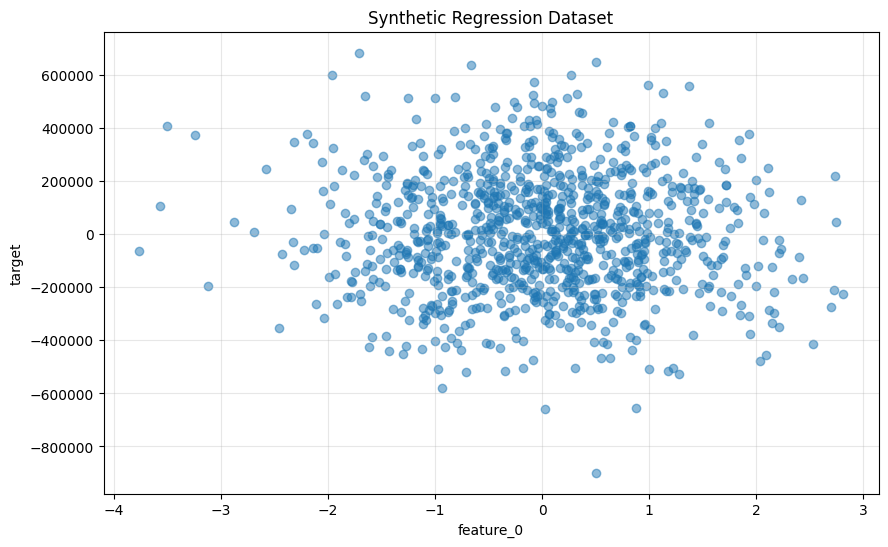

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y, alpha=0.5)
plt.xlabel("feature_0")
plt.ylabel("target")
plt.title("Synthetic Regression Dataset")
plt.grid(alpha=0.3)
plt.show()

## Analisis Dataset

Scatter plot menunjukkan bahwa hubungan antara `feature_0` dan target tidak sepenuhnya jelas secara visual. Hal ini wajar karena target sebenarnya dibentuk dari banyak fitur, bukan hanya satu fitur. Selain itu, dataset memiliki noise, multicollinearity, dan komponen non-linear kecil.

Kondisi seperti ini berguna untuk melihat bagaimana linear regression dan regularized regression bekerja ketika fitur berjumlah banyak dan saling berkorelasi.

## Train-Test Split

Dataset dibagi menjadi training set dan test set. Training set digunakan untuk melatih model, sedangkan test set digunakan untuk mengukur kemampuan generalisasi model terhadap data baru.

In [4]:
X_full = df[feature_names]
y_full = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=123
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])
print("Jumlah fitur:", X_train.shape[1])

Jumlah data training: 800
Jumlah data testing: 200
Jumlah fitur: 100


## Linear Regression

Linear Regression digunakan sebagai baseline model. Model ini tidak memiliki regularization, sehingga seluruh koefisien bebas menyesuaikan data training.

Pada dataset yang memiliki multicollinearity, koefisien model dapat menjadi besar dan tidak stabil. Hal ini bisa meningkatkan risiko overfitting.

In [5]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

pd.DataFrame({
    "Metric": ["MSE", "RMSE", "MAE", "R2"],
    "Value": [mse_linear, rmse_linear, mae_linear, r2_linear]
})

,Metric,Value
0,MSE,4.655059e+10
1,RMSE,2.157559e+05
2,MAE,1.735971e+05
3,R2,6.476696e-02


## Rumus Metrik Evaluasi Regresi

### Mean Squared Error

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

MSE mengukur rata-rata kuadrat error. Nilai yang lebih kecil menunjukkan model lebih baik.

### Root Mean Squared Error

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

RMSE memiliki satuan yang sama dengan target, sehingga lebih mudah diinterpretasikan dibandingkan MSE.

### Mean Absolute Error

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

MAE mengukur rata-rata error absolut. MAE lebih tidak sensitif terhadap outlier dibandingkan MSE.

### R-Squared

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

Keterangan:

- $y_i$ = nilai aktual
- $\hat{y}_i$ = nilai prediksi
- $\bar{y}$ = rata-rata nilai target aktual
- $n$ = jumlah data

Nilai $R^2$ menunjukkan proporsi variasi target yang dapat dijelaskan oleh model.

## Visualisasi Linear Regression Fit

Karena model menggunakan 100 fitur, garis regresi di plot berikut hanya ditampilkan terhadap `feature_0`. Fitur lain diatur ke nol untuk membuat visualisasi 2D sederhana.

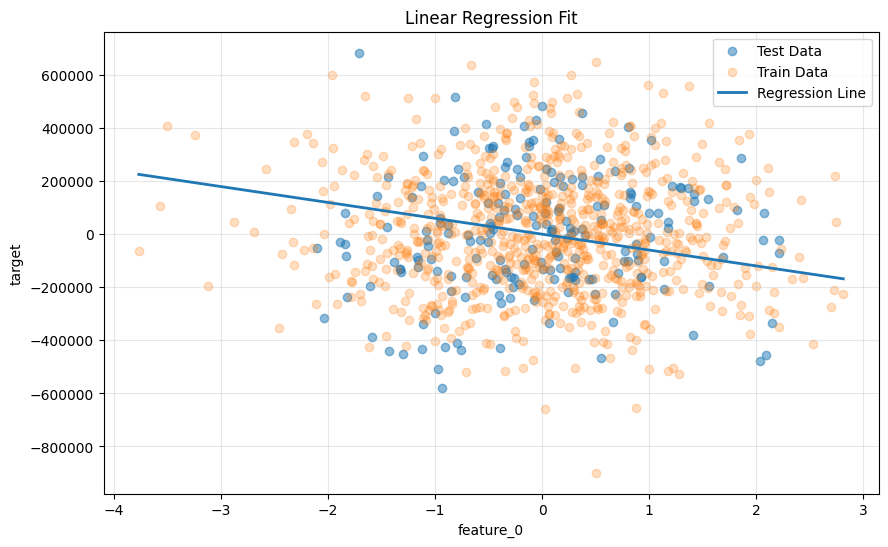

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test["feature_0"], y_test, alpha=0.5, label="Test Data")
plt.scatter(X_train["feature_0"], y_train, alpha=0.25, label="Train Data")

X_line = np.linspace(df["feature_0"].min(), df["feature_0"].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()
X_line_df = pd.DataFrame(X_line_full, columns=feature_names)
y_line = linear_model.predict(X_line_df)

plt.plot(X_line, y_line, label="Regression Line", linewidth=2)
plt.xlabel("feature_0")
plt.ylabel("target")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Ridge and Lasso Regression

Ridge dan Lasso adalah pengembangan dari linear regression yang menggunakan regularization. Regularization menambahkan penalti pada fungsi loss agar model tidak terlalu kompleks.

Perbedaan utamanya:

| Model | Jenis Penalti | Efek Utama |
|---|---|---|
| Ridge | L2 | Mengecilkan koefisien, tetapi biasanya tidak membuatnya nol |
| Lasso | L1 | Dapat membuat sebagian koefisien menjadi nol |
| ElasticNet | L1 + L2 | Kombinasi antara shrinkage dan feature selection |

Parameter utama pada Ridge dan Lasso adalah `alpha`. Semakin besar `alpha`, semakin kuat regularization yang diberikan.

## Rumus Ridge Regression

Ridge Regression menambahkan penalti L2 pada fungsi loss OLS.

$$
Loss_{Ridge} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p}\beta_j^2
$$

Keterangan:

- $y_i$ = nilai target aktual
- $\hat{y}_i$ = nilai prediksi
- $\alpha$ = kekuatan regularization
- $\beta_j$ = koefisien fitur ke-$j$
- $p$ = jumlah fitur

Penalti L2 mendorong koefisien menjadi lebih kecil, tetapi biasanya tidak membuat koefisien tepat menjadi nol. Ridge cocok ketika banyak fitur masih dianggap relevan, tetapi koefisiennya perlu dikontrol agar tidak terlalu besar.

## Rumus Lasso Regression

Lasso Regression menambahkan penalti L1 pada fungsi loss.

$$
Loss_{Lasso} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p}|\beta_j|
$$

Keterangan:

- $\alpha$ = kekuatan regularization
- $|\beta_j|$ = nilai absolut koefisien fitur ke-$j$

Penalti L1 dapat membuat beberapa koefisien menjadi tepat nol. Dengan demikian, Lasso dapat berperan sebagai metode feature selection.

## Implementasi Ridge dan Lasso

Pada contoh berikut, Linear Regression, Ridge, dan Lasso dibandingkan menggunakan dataset yang sama.

In [7]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

lasso_model = Lasso(alpha=10.0, max_iter=10000, tol=0.001)
lasso_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

metrics_df = pd.DataFrame({
    "Model": ["Ridge Regression", "Lasso Regression", "Linear Regression"],
    "MSE": [
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_linear)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_linear))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_linear)
    ],
    "R2": [
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_linear)
    ]
}).sort_values("MSE")

metrics_df

,Model,MSE,RMSE,MAE,R2
0,Ridge Regression,4.534109e+10,212934.477702,171751.465943,0.089067
1,Lasso Regression,4.637711e+10,215353.456016,173370.734325,0.068252
2,Linear Regression,4.655059e+10,215755.859875,173597.055729,0.064767


## Analisis Ridge dan Lasso

Ridge biasanya lebih stabil pada data yang memiliki multicollinearity karena koefisien fitur dikontrol melalui penalti L2. Lasso dapat menghasilkan model yang lebih sparse karena beberapa koefisien dapat menjadi nol.

Namun, performa terbaik tidak selalu sama untuk semua dataset. Jika hampir semua fitur relevan, Ridge sering lebih aman. Jika banyak fitur tidak relevan, Lasso bisa lebih berguna karena sekaligus melakukan feature selection.

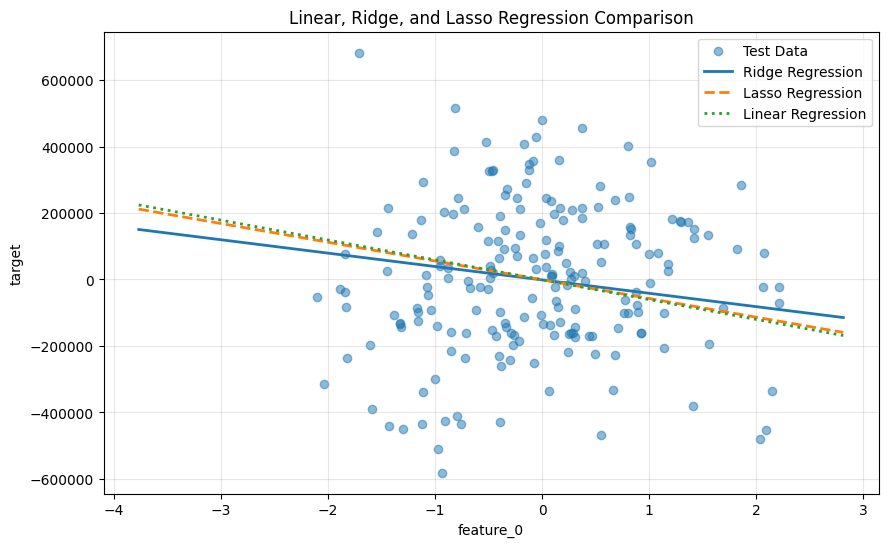

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test["feature_0"], y_test, alpha=0.5, label="Test Data")

y_line_ridge = ridge_model.predict(X_line_df)
y_line_lasso = lasso_model.predict(X_line_df)
y_line_linear = linear_model.predict(X_line_df)

plt.plot(X_line, y_line_ridge, label="Ridge Regression", linewidth=2)
plt.plot(X_line, y_line_lasso, label="Lasso Regression", linestyle="--", linewidth=2)
plt.plot(X_line, y_line_linear, label="Linear Regression", linestyle=":", linewidth=2)

plt.xlabel("feature_0")
plt.ylabel("target")
plt.title("Linear, Ridge, and Lasso Regression Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Perbandingan Koefisien Linear, Ridge, dan Lasso

Koefisien model dapat dianalisis untuk melihat dampak regularization. Ridge biasanya mengecilkan nilai koefisien, sedangkan Lasso dapat membuat sebagian koefisien menjadi nol.

In [9]:
coef_compare = pd.DataFrame({
    "feature": feature_names,
    "linear_coef": linear_model.coef_,
    "ridge_coef": ridge_model.coef_,
    "lasso_coef": lasso_model.coef_
})

coef_compare["abs_linear_coef"] = np.abs(coef_compare["linear_coef"])
coef_compare_sorted = coef_compare.sort_values("abs_linear_coef", ascending=False)

print("Jumlah koefisien Lasso yang menjadi nol:", np.sum(lasso_model.coef_ == 0))
coef_compare_sorted.head(15)

Jumlah koefisien Lasso yang menjadi nol: 0


,feature,linear_coef,ridge_coef,lasso_coef,abs_linear_coef
66,feature_66,-168982.704786,-122266.982109,-165217.233313,168982.704786
16,feature_16,160857.416958,114007.076572,157035.340269,160857.416958
2,feature_2,-134928.902685,-105275.950288,-132794.749408,134928.902685
53,feature_53,131372.059841,102922.211463,128804.131111,131372.059841
96,feature_96,-125116.152755,-95113.471625,-122431.864894,125116.152755
46,feature_46,123408.439272,93818.183601,120815.152606,123408.439272
31,feature_31,120289.788918,94642.478662,118269.027398,120289.788918
18,feature_18,120265.841326,91278.279818,117991.041221,120265.841326
93,feature_93,-118629.991299,-92282.799975,-116279.161300,118629.991299
52,feature_52,116693.806656,87900.145474,114665.320493,116693.806656


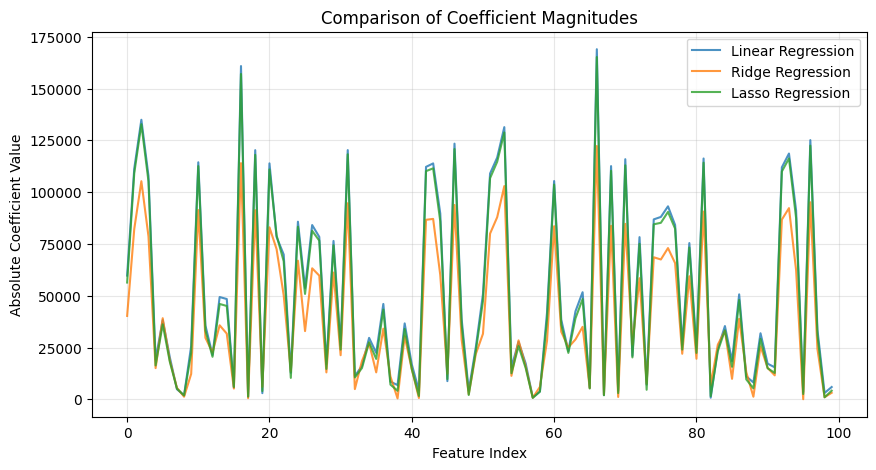

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(np.abs(linear_model.coef_), label="Linear Regression", alpha=0.8)
plt.plot(np.abs(ridge_model.coef_), label="Ridge Regression", alpha=0.8)
plt.plot(np.abs(lasso_model.coef_), label="Lasso Regression", alpha=0.8)
plt.xlabel("Feature Index")
plt.ylabel("Absolute Coefficient Value")
plt.title("Comparison of Coefficient Magnitudes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## ElasticNet and Regularization

ElasticNet adalah model regularized regression yang menggabungkan penalti L1 dan L2. Model ini dapat digunakan ketika dataset memiliki fitur yang saling berkorelasi dan juga terdapat kemungkinan banyak fitur tidak relevan.

ElasticNet memiliki dua parameter penting:

- `alpha`: mengatur kekuatan regularization secara keseluruhan.
- `l1_ratio`: mengatur proporsi penalti L1 dan L2.

Jika `l1_ratio = 1`, ElasticNet berperilaku seperti Lasso. Jika `l1_ratio = 0`, ElasticNet berperilaku seperti Ridge.

## Rumus ElasticNet

ElasticNet menggabungkan penalti L1 dan L2 dalam satu fungsi loss.

$$
Loss_{ElasticNet}
=
\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
+
\alpha
\left(
\rho \sum_{j=1}^{p}|\beta_j|
+
\frac{1-\rho}{2}\sum_{j=1}^{p}\beta_j^2
\right)
$$

Keterangan:

- $\alpha$ = kekuatan regularization secara keseluruhan
- $\rho$ = `l1_ratio`, proporsi penalti L1
- $|\beta_j|$ = penalti L1
- $\beta_j^2$ = penalti L2
- $p$ = jumlah fitur

Ketika $\rho$ mendekati 1, model lebih mirip Lasso. Ketika $\rho$ mendekati 0, model lebih mirip Ridge.

## Implementasi ElasticNet

ElasticNet diterapkan pada dataset yang sama, kemudian hasilnya dibandingkan dengan Linear Regression, Ridge, dan Lasso.

In [11]:
elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    random_state=123,
    max_iter=10000,
    tol=1e-4
)

elastic_model.fit(X_train, y_train)
y_pred_elastic = elastic_model.predict(X_test)

elastic_result = pd.DataFrame({
    "Model": ["ElasticNet Regression"],
    "MSE": [mean_squared_error(y_test, y_pred_elastic)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_elastic))],
    "MAE": [mean_absolute_error(y_test, y_pred_elastic)],
    "R2": [r2_score(y_test, y_pred_elastic)]
})

all_metrics_df = pd.concat([metrics_df, elastic_result], ignore_index=True).sort_values("MSE")
all_metrics_df

,Model,MSE,RMSE,MAE,R2
3,ElasticNet Regression,4.261664e+10,206437.969777,167500.089485,0.143803
0,Ridge Regression,4.534109e+10,212934.477702,171751.465943,0.089067
1,Lasso Regression,4.637711e+10,215353.456016,173370.734325,0.068252
2,Linear Regression,4.655059e+10,215755.859875,173597.055729,0.064767


## Analisis ElasticNet

ElasticNet berusaha mengambil kelebihan Ridge dan Lasso. Penalti L2 membantu ketika fitur saling berkorelasi, sedangkan penalti L1 membantu mengurangi fitur yang kurang relevan.

Namun, ElasticNet memiliki lebih banyak hyperparameter, sehingga biasanya membutuhkan tuning untuk mendapatkan kombinasi `alpha` dan `l1_ratio` yang optimal.

## Coefficient Path pada ElasticNet

Coefficient path menunjukkan bagaimana nilai koefisien berubah ketika nilai regularization berubah. Semakin besar `alpha`, semakin kuat regularization, sehingga koefisien cenderung mengecil.

Pada plot berikut, beberapa kombinasi `alpha` dan `l1_ratio` digunakan untuk melihat perubahan koefisien.

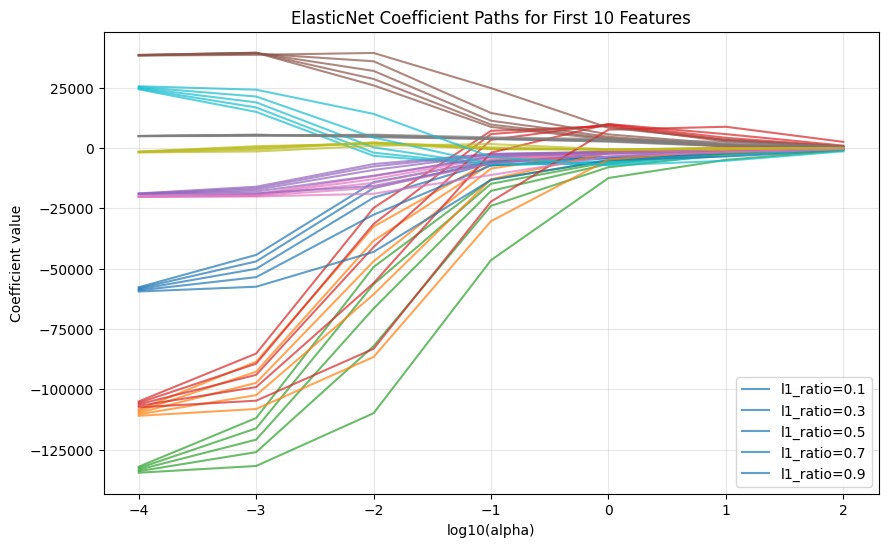

In [12]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

plt.figure(figsize=(10, 6))

for l1_ratio in l1_ratios:
    coefs = []
    for alpha in alphas:
        model = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            random_state=123,
            max_iter=10000,
            tol=1e-4
        )
        model.fit(X_train, y_train)
        coefs.append(model.coef_)

    coefs = np.array(coefs)

    # Agar visualisasi tidak terlalu ramai, tampilkan 10 fitur pertama saja
    for feature_idx in range(10):
        label = f"l1_ratio={l1_ratio}" if feature_idx == 0 else None
        plt.plot(
            np.log10(alphas),
            coefs[:, feature_idx],
            alpha=0.7,
            label=label
        )

plt.xlabel("log10(alpha)")
plt.ylabel("Coefficient value")
plt.title("ElasticNet Coefficient Paths for First 10 Features")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Interpretasi Coefficient Path

Plot coefficient path memperlihatkan bahwa ketika nilai `alpha` meningkat, nilai koefisien cenderung mengecil mendekati nol. Hal ini menunjukkan efek regularization.

Interpretasi umum:

- Sumbu X menunjukkan kekuatan regularization dalam skala log.
- Sumbu Y menunjukkan nilai koefisien model.
- Semakin ke kanan, regularization semakin kuat.
- Jika koefisien mendekati nol, fitur tersebut semakin kecil pengaruhnya.
- Jika `l1_ratio` lebih tinggi, model lebih cenderung membuat koefisien menjadi nol.

## Regularization Theory and Practice

Regularization adalah teknik untuk mengurangi overfitting dengan menambahkan penalti pada fungsi loss. Model yang terlalu kompleks dapat bekerja sangat baik pada data training, tetapi gagal pada data baru.

Tujuan regularization adalah mencari keseimbangan antara:

- **Goodness of fit:** seberapa baik model mengikuti data training.
- **Model simplicity:** seberapa sederhana model agar tetap mampu generalisasi.

Regularization mencegah model terlalu bergantung pada fitur tertentu dengan mengecilkan koefisien model.

## Bias-Variance Trade-Off

Regularization berkaitan erat dengan bias-variance trade-off.

- Model yang terlalu sederhana memiliki bias tinggi dan dapat mengalami underfitting.
- Model yang terlalu kompleks memiliki variance tinggi dan dapat mengalami overfitting.
- Regularization menambah constraint pada model sehingga variance dapat turun, meskipun bias dapat sedikit meningkat.

Secara konseptual:

$$
Expected\ Error = Bias^2 + Variance + Irreducible\ Error
$$

Keterangan:

- $Bias^2$ = error karena asumsi model terlalu sederhana
- $Variance$ = error karena model terlalu sensitif terhadap data training
- $Irreducible\ Error$ = noise yang tidak dapat dihilangkan oleh model

Regularization bertujuan menurunkan variance tanpa menaikkan bias terlalu besar.

## Tuning Alpha pada Ridge dan Lasso

Nilai `alpha` sangat memengaruhi kekuatan regularization. Jika terlalu kecil, model hampir sama seperti linear regression biasa. Jika terlalu besar, model bisa terlalu sederhana dan mengalami underfitting.

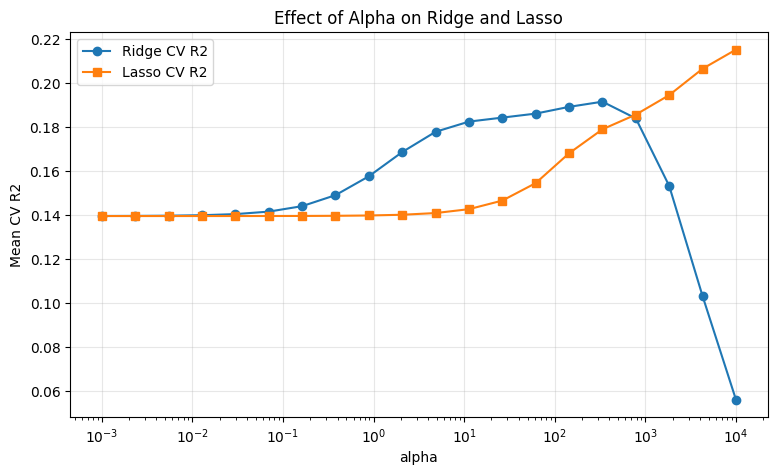

,alpha,ridge_cv_r2,lasso_cv_r2
0,0.001000,0.139732,0.139702
1,0.002336,0.139772,0.139703
2,0.005456,0.139865,0.139704
3,0.012743,0.140082,0.139706
4,0.029764,0.140582,0.139711


In [13]:
alpha_grid = np.logspace(-3, 4, 20)

ridge_scores = []
lasso_scores = []

for alpha in alpha_grid:
    ridge_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])
    lasso_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=10000))
    ])

    ridge_cv = cross_val_score(ridge_pipe, X_full, y_full, cv=5, scoring="r2").mean()
    lasso_cv = cross_val_score(lasso_pipe, X_full, y_full, cv=5, scoring="r2").mean()

    ridge_scores.append(ridge_cv)
    lasso_scores.append(lasso_cv)

plt.figure(figsize=(9, 5))
plt.semilogx(alpha_grid, ridge_scores, marker="o", label="Ridge CV R2")
plt.semilogx(alpha_grid, lasso_scores, marker="s", label="Lasso CV R2")
plt.xlabel("alpha")
plt.ylabel("Mean CV R2")
plt.title("Effect of Alpha on Ridge and Lasso")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({
    "alpha": alpha_grid,
    "ridge_cv_r2": ridge_scores,
    "lasso_cv_r2": lasso_scores
}).head()

## Grid Search untuk ElasticNet

Karena ElasticNet memiliki `alpha` dan `l1_ratio`, tuning hyperparameter dapat dilakukan menggunakan `GridSearchCV`.

In [14]:
elastic_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=10000, random_state=123))
])

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid = GridSearchCV(
    elastic_pipe,
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)
print("Test R2:", grid.score(X_test, y_test))

Best parameters: {'model__alpha': 1, 'model__l1_ratio': 0.5}
Best CV R2: 0.19224365506491273
Test R2: 0.14401063776751455


In [15]:
grid_results = pd.DataFrame(grid.cv_results_)

grid_results[[
    "param_model__alpha",
    "param_model__l1_ratio",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score").head(10)

,param_model__alpha,param_model__l1_ratio,mean_test_score,std_test_score,rank_test_score
17,1.0,0.5,0.192244,0.047091,1
16,1.0,0.3,0.191429,0.042999,2
18,1.0,0.7,0.190217,0.052245,3
15,1.0,0.1,0.188948,0.039659,4
24,10.0,0.9,0.187333,0.038190,5
19,1.0,0.9,0.182909,0.059090,6
10,0.1,0.1,0.182275,0.059514,7
11,0.1,0.3,0.180854,0.060408,8
12,0.1,0.5,0.179059,0.061415,9
13,0.1,0.7,0.176293,0.062701,10


## Regression and Regularization pada Data Non-Linear

Linear regression hanya mampu membentuk hubungan linear terhadap fitur asli. Jika hubungan data non-linear, model linear biasa dapat mengalami underfitting.

Salah satu cara memperluas linear model adalah menggunakan **polynomial features**. Polynomial regression tetap menggunakan model linear, tetapi fitur input diperluas menjadi pangkat-pangkat fitur asli.

## Rumus Polynomial Regression

Untuk satu fitur $x$, polynomial regression derajat 3 dapat ditulis sebagai:

$$
\hat{y} = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3
$$

Secara umum, untuk derajat $d$:

$$
\hat{y} = \beta_0 + \sum_{j=1}^{d}\beta_jx^j
$$

Keterangan:

- $d$ = degree polynomial
- $x^j$ = fitur baru hasil pangkat fitur asli
- $\beta_j$ = koefisien untuk fitur polynomial ke-$j$

Walaupun bentuknya melengkung terhadap $x$, model ini tetap linear terhadap parameter $\beta$.

## Membuat Dataset Non-Linear

Dataset berikut dibuat dengan komponen linear dan sinusoidal. Tujuannya adalah menunjukkan bahwa model linear biasa kurang fleksibel untuk hubungan non-linear.

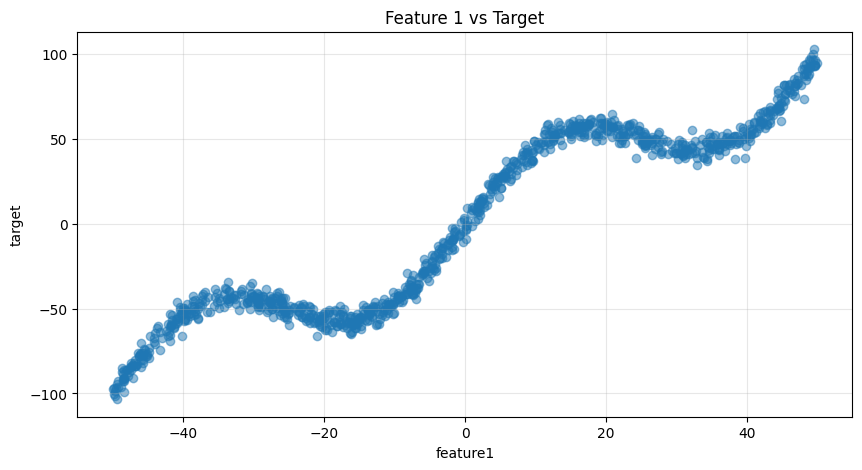

,feature1,target
0,19.646919,56.351092
1,-21.386067,-58.342527
2,-27.314855,-43.710217
3,5.131477,20.920295
4,21.946897,52.175806


In [16]:
np.random.seed(123)

n_samples = 1000
X_nonlinear = np.random.uniform(-50, 50, (n_samples, 1))

y_nonlinear = (
    2 * X_nonlinear[:, 0]
    + 27 * np.sin(X_nonlinear[:, 0] / 8)
    + np.random.normal(0, 4, n_samples)
)

nonlinear_data = pd.DataFrame(X_nonlinear, columns=["feature1"])
nonlinear_data["target"] = y_nonlinear

plt.figure(figsize=(10, 5))
plt.scatter(nonlinear_data["feature1"], nonlinear_data["target"], alpha=0.5)
plt.xlabel("feature1")
plt.ylabel("target")
plt.title("Feature 1 vs Target")
plt.grid(alpha=0.3)
plt.show()

nonlinear_data.head()

## Polynomial Regression dengan Berbagai Degree

Kita mencoba beberapa degree polynomial dan membandingkan performanya menggunakan MSE dan R². Degree yang lebih tinggi dapat menangkap pola yang lebih kompleks, tetapi juga meningkatkan risiko overfitting.

c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Lenovo\AppData\Local\Programs\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialF

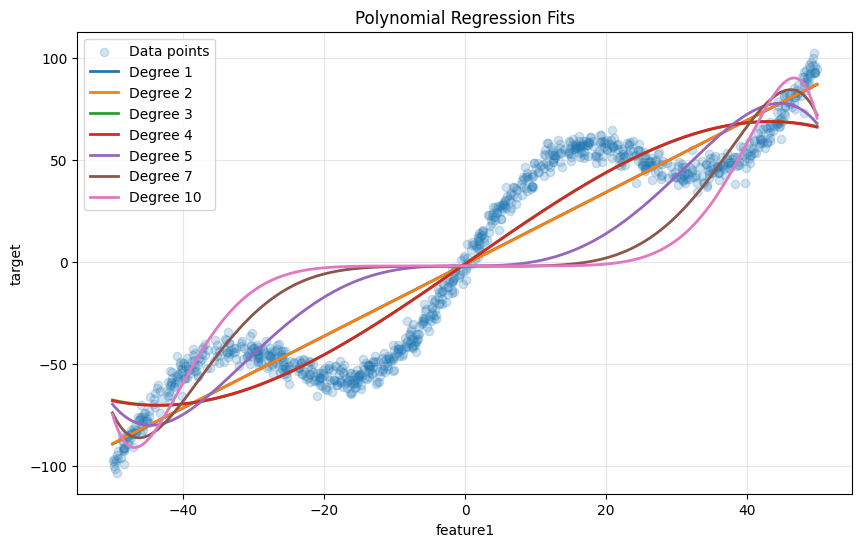

,Degree,MSE,RMSE,R2
3,4,268.230101,16.377732,0.907885
2,3,268.477397,16.385280,0.907800
1,2,316.818454,17.799395,0.891199
0,1,317.005037,17.804635,0.891135
4,5,811.070884,28.479306,0.721464
5,7,1093.385809,33.066385,0.624512
6,10,1257.566022,35.462177,0.568130


In [17]:
X_poly_base = nonlinear_data[["feature1"]]
y_poly_base = nonlinear_data["target"]

degrees = [1, 2, 3, 4, 5, 7, 10]
poly_results = []

plt.figure(figsize=(10, 6))
plt.scatter(X_poly_base["feature1"], y_poly_base, alpha=0.2, label="Data points")

X_plot_smooth = np.linspace(
    X_poly_base["feature1"].min(),
    X_poly_base["feature1"].max(),
    1000
).reshape(-1, 1)

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_poly_base)

    X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
        X_poly,
        y_poly_base,
        test_size=0.2,
        random_state=123
    )

    poly_model = LinearRegression()
    poly_model.fit(X_train_p, y_train_p)
    y_pred_p = poly_model.predict(X_test_p)

    mse = mean_squared_error(y_test_p, y_pred_p)
    r2 = r2_score(y_test_p, y_pred_p)

    poly_results.append({
        "Degree": degree,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2
    })

    X_plot_poly = poly.transform(X_plot_smooth)
    y_plot = poly_model.predict(X_plot_poly)
    plt.plot(X_plot_smooth, y_plot, linewidth=2, label=f"Degree {degree}")

plt.xlabel("feature1")
plt.ylabel("target")
plt.title("Polynomial Regression Fits")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

poly_results_df = pd.DataFrame(poly_results).sort_values("MSE")
poly_results_df

## Analisis Polynomial Regression

Degree 1 sama dengan linear regression biasa. Jika pola data melengkung, degree rendah mungkin tidak cukup menangkap pola. Degree yang lebih tinggi dapat mengikuti pola non-linear dengan lebih baik.

Namun, degree yang terlalu tinggi dapat membuat model terlalu mengikuti noise pada data training. Oleh karena itu, pemilihan degree sebaiknya tidak hanya berdasarkan R² tertinggi, tetapi juga memperhatikan residual, MSE, dan kemampuan generalisasi.

## Residual Plot untuk Model Polynomial Terbaik

Residual adalah selisih antara nilai aktual dan prediksi.

$$
Residual_i = y_i - \hat{y}_i
$$

Jika model baik, residual cenderung tersebar acak di sekitar nol. Jika masih ada pola tertentu pada residual, berarti model belum menangkap struktur data dengan baik.

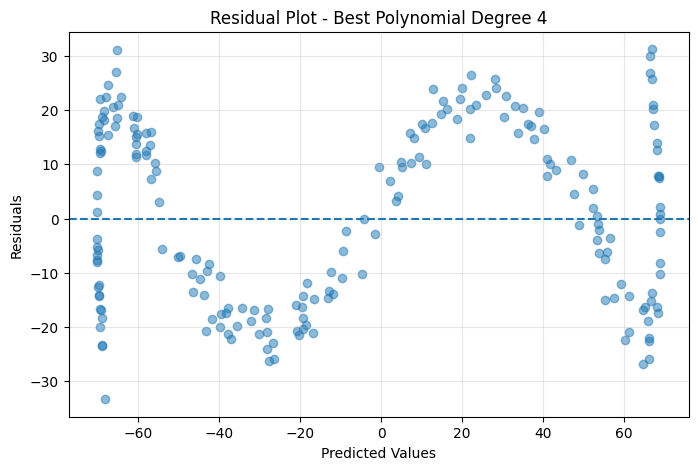

In [18]:
best_degree = int(poly_results_df.iloc[0]["Degree"])

best_poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_best_poly = best_poly.fit_transform(X_poly_base)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_best_poly,
    y_poly_base,
    test_size=0.2,
    random_state=123
)

best_poly_model = LinearRegression()
best_poly_model.fit(X_train_b, y_train_b)

y_pred_best = best_poly_model.predict(X_test_b)
residuals = y_test_b - y_pred_best

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - Best Polynomial Degree {best_degree}")
plt.grid(alpha=0.3)
plt.show()

## Polynomial Regression dengan Regularization

Polynomial features dapat menghasilkan banyak fitur baru. Jika degree tinggi, model bisa menjadi sangat kompleks. Karena itu, regularization seperti Ridge sering digunakan bersama polynomial regression.

Pipeline berikut menggabungkan:

1. PolynomialFeatures
2. StandardScaler
3. Ridge Regression

In [19]:
poly_ridge_pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid_poly_ridge = {
    "poly__degree": [1, 2, 3, 4, 5, 7, 10],
    "ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

X_train_nr, X_test_nr, y_train_nr, y_test_nr = train_test_split(
    X_poly_base,
    y_poly_base,
    test_size=0.2,
    random_state=123
)

grid_poly_ridge = GridSearchCV(
    poly_ridge_pipe,
    param_grid_poly_ridge,
    cv=5,
    scoring="r2"
)

grid_poly_ridge.fit(X_train_nr, y_train_nr)

print("Best parameters:", grid_poly_ridge.best_params_)
print("Best CV R2:", grid_poly_ridge.best_score_)
print("Test R2:", grid_poly_ridge.score(X_test_nr, y_test_nr))

Best parameters: {'poly__degree': 10, 'ridge__alpha': 0.001}
Best CV R2: 0.9944722214879395
Test R2: 0.9948474530033986


## Perbandingan Model Akhir

Tabel berikut merangkum beberapa model yang digunakan pada chapter ini. Tujuannya bukan hanya mencari angka terbaik, tetapi memahami bagaimana regularization dan transformasi fitur memengaruhi performa model.

In [20]:
final_models = []

# Linear
final_models.append({
    "Model": "Linear Regression",
    "MSE": mse_linear,
    "RMSE": rmse_linear,
    "MAE": mae_linear,
    "R2": r2_linear
})

# Ridge
final_models.append({
    "Model": "Ridge Regression",
    "MSE": mean_squared_error(y_test, y_pred_ridge),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    "MAE": mean_absolute_error(y_test, y_pred_ridge),
    "R2": r2_score(y_test, y_pred_ridge)
})

# Lasso
final_models.append({
    "Model": "Lasso Regression",
    "MSE": mean_squared_error(y_test, y_pred_lasso),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    "MAE": mean_absolute_error(y_test, y_pred_lasso),
    "R2": r2_score(y_test, y_pred_lasso)
})

# ElasticNet
final_models.append({
    "Model": "ElasticNet Regression",
    "MSE": mean_squared_error(y_test, y_pred_elastic),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_elastic)),
    "MAE": mean_absolute_error(y_test, y_pred_elastic),
    "R2": r2_score(y_test, y_pred_elastic)
})

pd.DataFrame(final_models).sort_values("MSE")

,Model,MSE,RMSE,MAE,R2
3,ElasticNet Regression,4.261664e+10,206437.969777,167500.089485,0.143803
1,Ridge Regression,4.534109e+10,212934.477702,171751.465943,0.089067
2,Lasso Regression,4.637711e+10,215353.456016,173370.734325,0.068252
0,Linear Regression,4.655059e+10,215755.859875,173597.055729,0.064767


## Ringkasan Konsep Penting

| Konsep | Penjelasan |
|---|---|
| Linear Regression | Model regresi yang memprediksi target sebagai kombinasi linear fitur |
| OLS | Metode yang meminimalkan jumlah kuadrat error |
| MSE | Rata-rata kuadrat error |
| R² | Proporsi variasi target yang dijelaskan model |
| Multicollinearity | Kondisi ketika fitur saling berkorelasi kuat |
| Ridge | Linear regression dengan penalti L2 |
| Lasso | Linear regression dengan penalti L1 |
| ElasticNet | Kombinasi penalti L1 dan L2 |
| Alpha | Parameter kekuatan regularization |
| l1_ratio | Parameter proporsi L1 dan L2 pada ElasticNet |
| Polynomial Regression | Linear model pada fitur hasil transformasi polynomial |
| Residual | Selisih antara nilai aktual dan prediksi |

## Kesimpulan Chapter

Chapter ini menjelaskan bahwa linear model merupakan fondasi penting dalam machine learning, khususnya untuk regresi. Linear Regression sederhana mudah dipahami, tetapi dapat bermasalah ketika data memiliki banyak fitur, multicollinearity, atau noise.

Regularization membantu mengurangi kompleksitas model dengan menambahkan penalti pada koefisien. Ridge menggunakan penalti L2 untuk mengecilkan koefisien, Lasso menggunakan penalti L1 yang dapat membuat sebagian koefisien menjadi nol, sedangkan ElasticNet menggabungkan keduanya.

Poin penting dari chapter ini:

- Linear Regression memodelkan hubungan target dan fitur melalui kombinasi linear.
- MSE, RMSE, MAE, dan R² digunakan untuk mengevaluasi regresi.
- Ridge Regression berguna untuk mengontrol koefisien pada data multicollinear.
- Lasso Regression berguna ketika banyak fitur diduga tidak relevan.
- ElasticNet memberi keseimbangan antara Ridge dan Lasso.
- Regularization membantu mengurangi overfitting dengan menekan kompleksitas model.
- Polynomial Regression memungkinkan linear model menangani pola non-linear.
- Semakin kompleks model, semakin penting evaluasi dan regularization.

Secara keseluruhan, chapter ini menunjukkan bahwa model linear dapat menjadi sangat fleksibel jika dikombinasikan dengan regularization dan feature transformation yang tepat.